# Exoplanet Analysis: Discovery Methods vs Planet Properties

## Research Question
How do exoplanet orbital period and size differ depending on discovery method?

## Dataset
This dataset comes from the NASA Exoplanet Archive and includes confirmed exoplanets with their orbital period, radius, and discovery method.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Data
df = pd.read_csv("exoplanet_rawdata.csv", comment="#")

# Clean column names
df.columns = df.columns.str.strip()

# Select relevant columns
df = df[['discoverymethod', 'pl_orbper', 'pl_rade']]

# Remove missing values
df = df.dropna()

# Basic checks
print("Data shape:", df.shape)
print(df.head())

/tmp/ipykernel_11503/516923436.py:7: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("exoplanets.csv", comment="#")


Data shape: (25141, 3)
     discoverymethod  pl_orbper   pl_rade
117  Radial Velocity   0.736547  1.947000
122  Radial Velocity   0.736547  1.875000
123  Radial Velocity   0.736546  2.173000
124  Radial Velocity   0.736543  1.856000
127  Radial Velocity   0.736546  2.023112


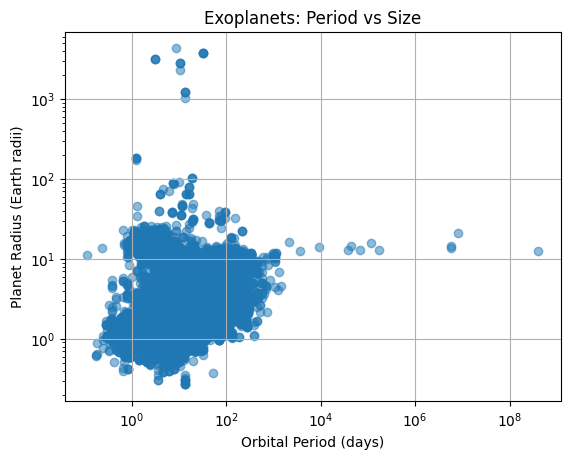

In [ ]:
# Plot 1: Full Dataset (log scale)
plt.figure()
plt.scatter(df['pl_orbper'], df['pl_rade'], alpha=0.5)
plt.xlabel("Orbital Period (days)")
plt.ylabel("Planet Radius (Earth radii)")
plt.title("Exoplanets: Period vs Size")
plt.xscale('log')
plt.yscale('log')
plt.grid(True)
plt.show()

## Interpretation

The scatter plot shows that exoplanets span a wide range of orbital periods and sizes.

Most planets appear clustered at shorter orbital periods and smaller radii. This suggests that smaller, close-in planets are more commonly detected.

Using a logarithmic scale reveals patterns in the data that would be difficult to see on a normal scale, especially across large ranges of values.

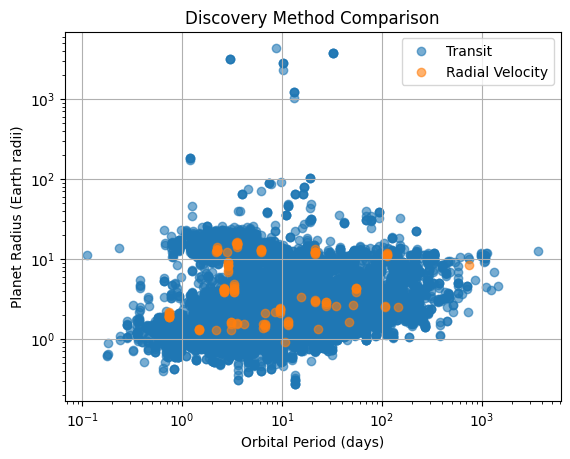

In [ ]:
# Filter Discovery Methods
methods = ['Transit', 'Radial Velocity']
df2 = df[df['discoverymethod'].isin(methods)]

# Plot 2: Comparison
plt.figure()

for method in methods:
    subset = df2[df2['discoverymethod'] == method]
    plt.scatter(subset['pl_orbper'], subset['pl_rade'], label=method, alpha=0.6)

plt.xlabel("Orbital Period (days)")
plt.ylabel("Planet Radius (Earth radii)")
plt.title("Discovery Method Comparison")

plt.xscale('log')
plt.yscale('log')

plt.legend()
plt.grid(True)
plt.show()

## Interpretation

Transit-detected planets are concentrated at shorter orbital periods. This is expected because planets that orbit close to their stars are more likely to pass in front of them, making them easier to detect using the transit method.

Radial velocity planets are more spread out across orbital periods. This method can detect planets that do not transit their stars, allowing it to find planets at greater distances.

This comparison shows that different detection methods introduce observational bias into the dataset.

## Conclusion

This analysis shows that the method used to detect exoplanets strongly influences the types of planets observed.

Transit methods tend to detect short-period planets, while radial velocity methods detect a broader range of orbital distances.

This demonstrates that the observed distribution of exoplanets is not only determined by physics, but also by limitations and biases in detection techniques.

## Limitations

- Missing data may affect the results
- Measurement uncertainties were not included
- Detection bias strongly influences the observed distributions
- Only two discovery methods were analyzed